In [1]:
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

In [2]:
# 1. Base Theme & Context
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 2. Fine-grained RC Parameters
plt.rcParams.update({
    # Fonts & Sizes
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,      # Suptitle size
    'axes.titlesize': 16,        # Ax title size (Standardized to 16)
    'axes.labelsize': 12,        # Ax label size

    # Weights (Bold globally)
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    # Structural Defaults
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [3]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):
    """
    Applies structural formatting only.
    Styling (size/bold) is now handled automatically by rcParams.
    """
    # Just set the text. The Global Config handles size/bolding.
    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Grid Logic (Structural)
    # Note: We must explicitly turn OFF the opposing grid
    # because seaborn defaults might keep it on.
    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [4]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)
df

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


In [5]:
def cal_Obesity(BMI):
    return abs((BMI / 22 - 1) * 100)

def cal_BMI(Height, Weight):
    return Weight/(Height/100)**2

In [6]:
df_bmi_profile = df[['Height','Weight','Body Mass Index (BMI)','Obesity (%)']].copy()

df_bmi_profile['Calculated BMI']    =  df_bmi_profile['Weight'] / (df_bmi_profile['Height']/100)**2
df_bmi_profile['BMI Variance']      =  df_bmi_profile['Body Mass Index (BMI)'] - df_bmi_profile['Calculated BMI']

df_bmi_profile['Calculated Obesity'] = df_bmi_profile['Body Mass Index (BMI)'].apply(cal_Obesity)
df_bmi_profile['Obesity Variance']   = df_bmi_profile['Obesity (%)'] - df_bmi_profile['Calculated Obesity']

df_bmi_clean_BMI = df_bmi_profile[abs(df_bmi_profile['BMI Variance']) < 0.1].copy()
df_bmi_clean_Obesity = df_bmi_profile[abs(df_bmi_profile['Obesity Variance']) < 1000].copy()

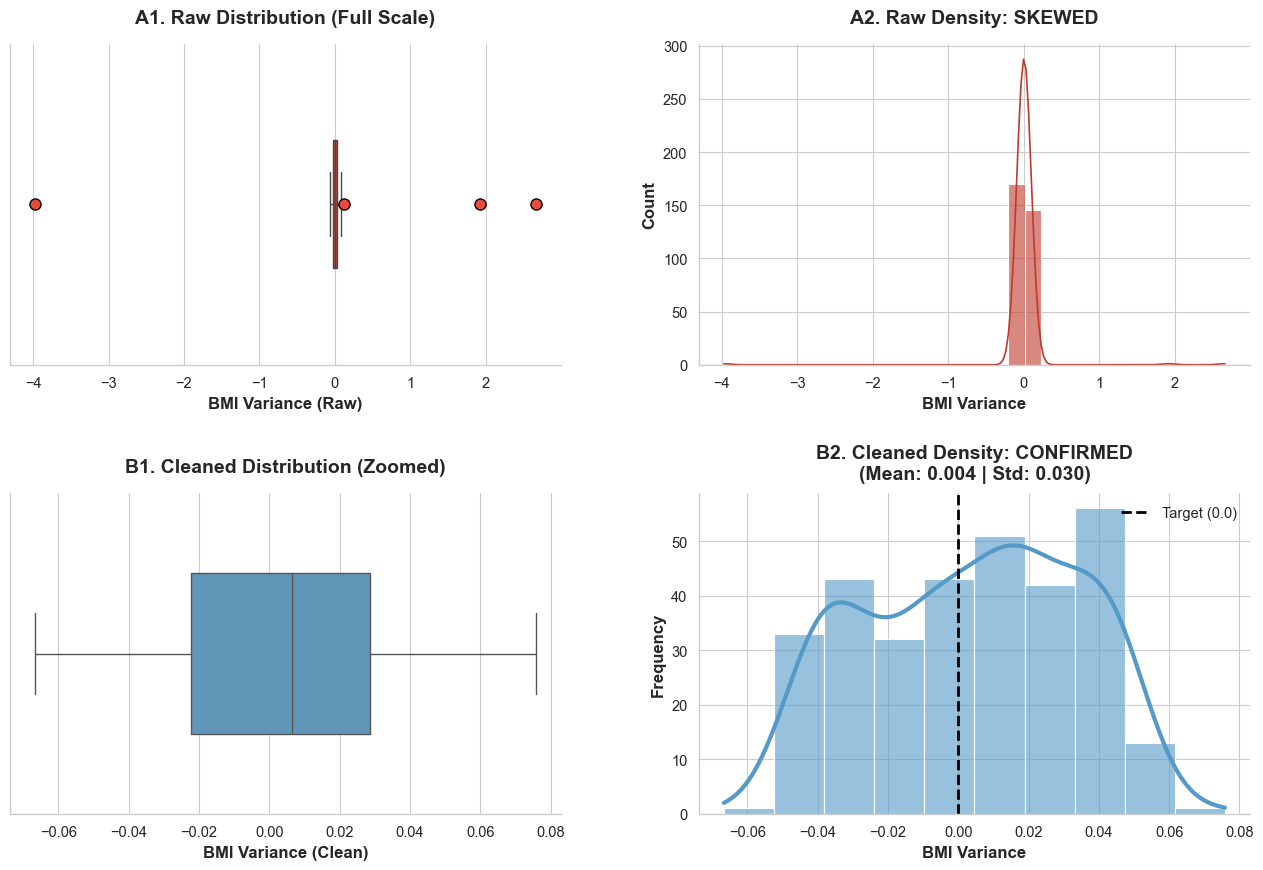

In [7]:
# 1. Configuration
col_target = 'BMI Variance'
# Assuming these dataframes exist in your environment
raw_data = df_bmi_profile[col_target].dropna()
clean_data = df_bmi_clean_BMI[col_target].dropna()

# 2. Setup Canvas
# sharex=False is CRITICAL here to keep the independent scaling shown in Image 1
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
plt.subplots_adjust(hspace=0.4, wspace=0.25)

# =================================================
# ROW A: RAW DATA (The "Crime Scene") - RED THEME
# =================================================

# A1. Boxplot
ax_a1 = axes[0, 0]
sns.boxplot(
    x=raw_data,
    ax=ax_a1,
    color='#C0392B',
    width=0.4,
    # Keep the solid red dots style from Image 1
    flierprops={"marker": "o", "markerfacecolor": "#E74C3C", "markeredgecolor": "black", "markersize": 8}
)
ax_a1.set_title("A1. Raw Distribution (Full Scale)", fontsize=14, fontweight='bold', pad=15)
ax_a1.set_xlabel("BMI Variance (Raw)", fontweight='bold')

# --- ANNOTATION BLOCK REMOVED HERE ---

# A2. Histogram
ax_a2 = axes[0, 1]
sns.histplot(x=raw_data, ax=ax_a2, color='#C0392B', bins=30, kde=True, alpha=0.6)
ax_a2.set_title("A2. Raw Density: SKEWED", fontsize=14, fontweight='bold', pad=15)
ax_a2.set_xlabel("BMI Variance", fontweight='bold')
ax_a2.set_ylabel("Count", fontweight='bold')

# =================================================
# ROW B: CLEANED DATA (The "Resolution") - BLUE THEME
# =================================================

# B1. Boxplot
ax_b1 = axes[1, 0]
sns.boxplot(
    x=clean_data,
    ax=ax_b1,
    color='#5499C7',
    width=0.5,
    flierprops={"marker": "x", "markeredgecolor": "#1F618D"}
)
ax_b1.set_title("B1. Cleaned Distribution (Zoomed)", fontsize=14, fontweight='bold', pad=15)
ax_b1.set_xlabel("BMI Variance (Clean)", fontweight='bold')

# B2. Histogram
ax_b2 = axes[1, 1]
sns.histplot(
    x=clean_data,
    ax=ax_b2,
    color='#5499C7',
    kde=True,
    alpha=0.6,
    line_kws={'linewidth': 3, 'color': '#154360'}
)

# Stats Header
r_mean = clean_data.mean()
r_std = clean_data.std()
ax_b2.set_title(f"B2. Cleaned Density: CONFIRMED\n(Mean: {r_mean:.3f} | Std: {r_std:.3f})",
                fontsize=14, fontweight='bold', pad=10)
ax_b2.set_xlabel("BMI Variance", fontweight='bold')
ax_b2.set_ylabel("Frequency", fontweight='bold')
ax_b2.axvline(0, color='black', linestyle='--', linewidth=2, label='Target (0.0)')
ax_b2.legend(loc='upper right')

plt.show()

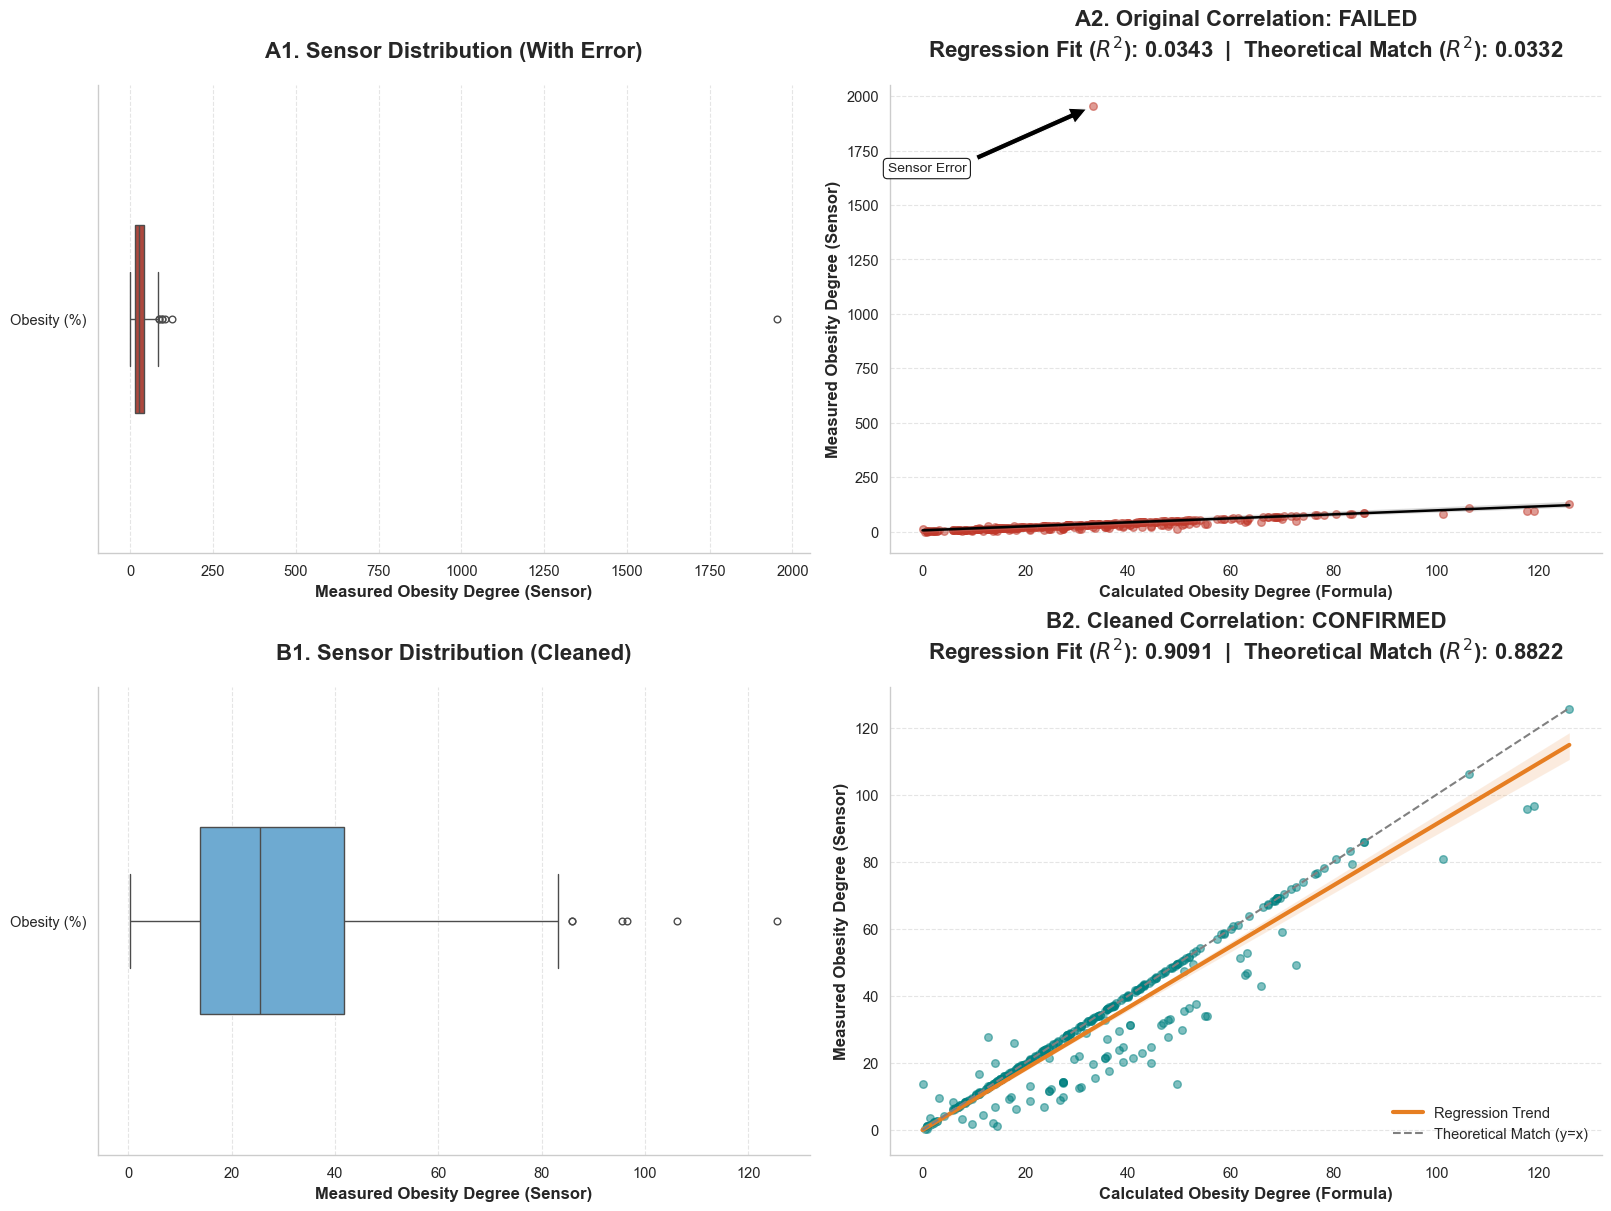

In [8]:
# Map your actual dataframes to the variable names used in the plotting block
df_orig = df_bmi_profile
df_clean = df_bmi_clean_Obesity
# --- METRIC 1: REGRESSION SCORE (Consistency) ---
# We square the Pearson R to get R^2 for the regression line
r_orig, _ = pearsonr(df_orig['Calculated Obesity'], df_orig['Obesity (%)'])
r2_regr_orig = r_orig**2

r_clean, _ = pearsonr(df_clean['Calculated Obesity'], df_clean['Obesity (%)'])
r2_regr_clean = r_clean**2

# --- METRIC 2: THEORETICAL SCORE (Accuracy) ---
# How well does it fit the PHYSICS FORMULA (y=x)?
def calc_theoretical_r2(df_input):
    # Order matters: (True, Pred) -> (Sensor, Formula)
    # This measures how well the formula predicts the sensor
    return r2_score(df_input['Obesity (%)'], df_input['Calculated Obesity'])

r2_theory_orig = calc_theoretical_r2(df_orig)
r2_theory_clean = calc_theoretical_r2(df_clean)

# 2. VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12), layout='constrained')

LABEL_Y_SENSOR = "Measured Obesity Degree (Sensor)"
LABEL_X_FORMULA = "Calculated Obesity Degree (Formula)"

# ==========================================
# ROW 1: SCENARIO A (Original)
# ==========================================
# 1A. Boxplot
sns.boxplot(data=df_orig[['Obesity (%)']], orient='h', ax=axes[0, 0], color='#C0392B', width=0.4)
format_plot(axes[0, 0], 'A1. Sensor Distribution (With Error)', LABEL_Y_SENSOR, '',True)

# 1B. Regression
sns.regplot(
    data=df_orig, x='Calculated Obesity', y='Obesity (%)', ax=axes[0, 1],
    color='#C0392B', scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'black', 'label': 'Regression Trend'}
)
# Outlier Annotation
outlier_row = df_orig[np.isclose(df_orig['Obesity (%)'], 1954.00)]
if not outlier_row.empty:
    x_out, y_out = outlier_row['Calculated Obesity'].values[0], outlier_row['Obesity (%)'].values[0]
    axes[0, 1].annotate("Sensor Error", xy=(x_out, y_out), xytext=(x_out-40, y_out-300),
                        arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10,
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9))

# [CHANGE] Unified R² Metrics
title_a = (f"A2. Original Correlation: FAILED\n"
           f"Regression Fit ($R^2$): {r2_regr_orig:.4f}  |  Theoretical Match ($R^2$): {r2_theory_orig:.4f}")
format_plot(axes[0, 1], title_a, LABEL_X_FORMULA, LABEL_Y_SENSOR)


# ==========================================
# ROW 2: SCENARIO B (Cleaned)
# ==========================================
# 2A. Boxplot
sns.boxplot(data=df_clean[['Obesity (%)']], orient='h', ax=axes[1, 0], color='#5DADE2', width=0.4)
format_plot(axes[1, 0], 'B1. Sensor Distribution (Cleaned)', LABEL_Y_SENSOR, '',True)

# 2B. Regression
sns.regplot(
    data=df_clean, x='Calculated Obesity', y='Obesity (%)', ax=axes[1, 1],
    color='teal', scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': '#E67E22', 'linewidth': 3, 'label': 'Regression Trend'}
)
limit = max(df_clean['Obesity (%)'].max(), df_clean['Calculated Obesity'].max())
axes[1, 1].plot([0, limit], [0, limit], color='gray', linestyle='--', linewidth=1.5, label='Theoretical Match (y=x)')

# [CHANGE] Unified R² Metrics
title_b = (f"B2. Cleaned Correlation: CONFIRMED\n"
           f"Regression Fit ($R^2$): {r2_regr_clean:.4f}  |  Theoretical Match ($R^2$): {r2_theory_clean:.4f}")
format_plot(axes[1, 1], title_b, LABEL_X_FORMULA, LABEL_Y_SENSOR)

axes[1, 1].legend(loc='lower right')

plt.show()




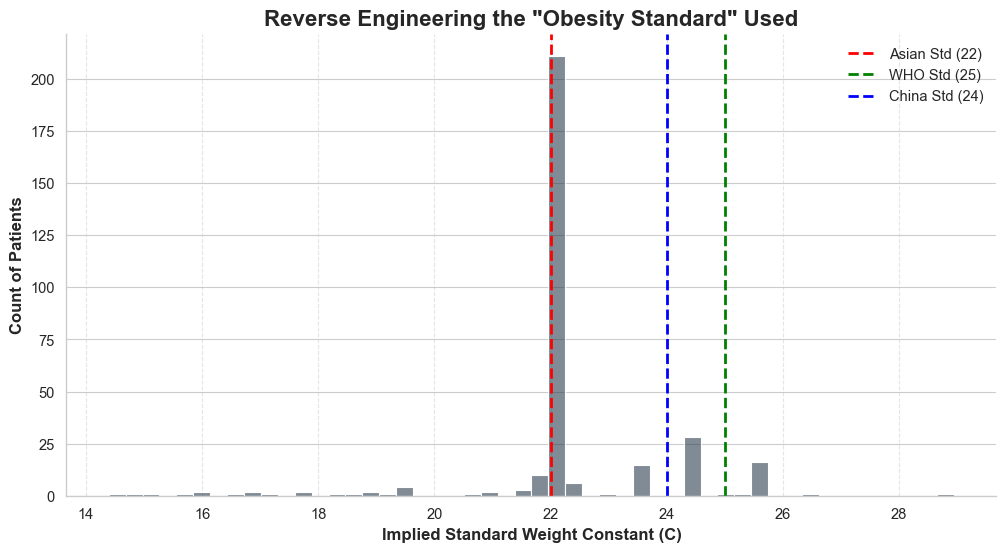

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Remove the "Year 1954" Error immediately
# We assume Obesity % cannot realistically exceed 200%
df_diagnosis = df_orig[df_orig['Obesity (%)'] < 200].copy()

# 2. Reverse Engineer the Constant 'C' for every row
# Formula derived: C = BMI / ((Obesity/100) + 1)
df_diagnosis['Implied_Standard'] = df_diagnosis['Body Mass Index (BMI)'] / ((df_diagnosis['Obesity (%)'] / 100) + 1)

# 3. Plot the Distribution of these Constants
plt.figure(figsize=(12, 6))

# Histogram
sns.histplot(x=df_diagnosis['Implied_Standard'], bins=50, kde=False, color='#2C3E50', alpha=0.6)

# Add "Standard" Lines to check against
plt.axvline(22.0, color='red', linestyle='--', linewidth=2, label='Asian Std (22)')
plt.axvline(25.0, color='green', linestyle='--', linewidth=2, label='WHO Std (25)')
plt.axvline(24.0, color='blue', linestyle='--', linewidth=2, label='China Std (24)')

plt.title('Reverse Engineering the "Obesity Standard" Used', fontsize=16, fontweight='bold')
plt.xlabel('Implied Standard Weight Constant (C)', fontweight='bold')
plt.ylabel('Count of Patients', fontweight='bold')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()